In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import h5py
import os
import argparse
from pathlib import Path
import imageio.v3 as iio
from skimage.transform import iradon
from ipywidgets import interact
import ipywidgets as widgets

## Load Data

In [2]:
raw_data_type       = '1D TFM Data'
raw_data_name       = 'Al Hole 5MHz 02022026'
reconstruction_dir  = '3D RECONSTRUCTION'
output_folder_name  = '3D reconstructed'
cwd                 = os.path.dirname(os.getcwd())
display_picture     = 'y' # y/n

# Input and Output paths.
IN_DIR  = os.path.join(cwd, 'DATA', raw_data_type, raw_data_name)
OUT_DIR = os.path.join(cwd, reconstruction_dir, output_folder_name, raw_data_name)

# Create output directory if it doesn't exist
os.makedirs(OUT_DIR, exist_ok=True)

# Find all files in directory which are .png files.  
images = [
    f for f in os.listdir(IN_DIR)
    if f.lower().endswith(".png")
    and os.path.isfile(os.path.join(IN_DIR, f))
]

print('Files available in directory:')
print(images)
print()
print(f'Input directory: {IN_DIR}')
print(f'Output directory: {OUT_DIR}')


def list_pngs(in_dir: str) -> list[str]:
    if not os.path.isdir(in_dir):
        raise FileNotFoundError(f"Input directory does not exist: {in_dir}")

    images = [
        f for f in os.listdir(in_dir)
        if f.lower().endswith(".png") and os.path.isfile(os.path.join(in_dir, f))
    ]
    images_sorted = sorted(images)
    return images_sorted


def load_projections_from_files(in_dir: str, files: list[str]) -> np.ndarray:
    imgs = []
    for fname in files:
        path = os.path.join(in_dir, fname)
        img = iio.imread(path)

        # Convert RGB/RGBA to grayscale
        if img.ndim == 3:
            img = img[..., :3].mean(axis=2)

        img = img.astype(np.float32)
        imgs.append(img)

    proj = np.stack(imgs, axis=0)  # (Nangles, H, W)

    # Normalize to [0,1]
    proj -= proj.min()
    denom = proj.max() - proj.min()
    if denom > 0:
        proj /= denom

    return proj

Files available in directory:
['Al_40_17_TFM_clean.png', 'Al_40_13_TFM_clean.png', 'Al_40_9_TFM_clean.png', 'Al_40_14_TFM_clean.png', 'Al_40_10_TFM_clean.png', 'Al_40_4_TFM_clean.png', 'Al_40_7_TFM_clean.png', 'Al_40_3_TFM_clean.png', 'Al_40_20_TFM_clean.png', 'Al_40_19_TFM_clean.png', 'Al_40_2_TFM_clean.png', 'Al_40_6_TFM_clean.png', 'Al_40_18_TFM_clean.png', 'Al_40_21_TFM_clean.png', 'Al_40_22_TFM_clean.png', 'Al_40_1_TFM_clean.png', 'Al_40_5_TFM_clean.png', 'Al_40_11_TFM_clean.png', 'Al_40_15_TFM_clean.png', 'Al_40_12_TFM_clean.png', 'Al_40_16_TFM_clean.png', 'Al_40_8_TFM_clean.png']

Input directory: /Users/theotabet/Documents/[4] UNIVERSITY/Y4/[5] GROUP INDUSTRIAL PROJECT/[2] CODE/signal-processing-G2066/DATA/1D TFM Data/Al Hole 5MHz 02022026
Output directory: /Users/theotabet/Documents/[4] UNIVERSITY/Y4/[5] GROUP INDUSTRIAL PROJECT/[2] CODE/signal-processing-G2066/3D RECONSTRUCTION/3D reconstructed/Al Hole 5MHz 02022026


## Pre-Process Images 

Crop and reconstruct slice by slice using the Inverse Radon Algorithm

In [3]:
def center_crop_to_square(proj: np.ndarray, size: int | None = None) -> np.ndarray:
    # proj: (N, H, W)
    n, h, w = proj.shape
    if size is None:
        size = min(h, w)
    if size is None or not isinstance(size, int):
        raise ValueError("Crop size must be an integer and cannot be None.")
    if size <= 0 or size > min(h, w):
        raise ValueError(f"Invalid crop size={size}, must be in (0, {min(h,w)}].")

    y0 = (h - size) // 2
    x0 = (w - size) // 2
    return proj[:, y0:y0 + size, x0:x0 + size]


def reconstruct_volume_slice_by_slice(
    proj: np.ndarray,
    theta_deg: np.ndarray,
    filter_name: str = "ramp",
    circle: bool = True,
) -> np.ndarray:
    """
    proj: (Nangles, H, W) where:
      - W is detector coordinate s (columns)
      - H indexes axial coordinate z (rows)

    returns volume: (H, W, W)
    """
    nang, h, w = proj.shape
    if theta_deg.shape[0] != nang:
        raise ValueError("theta_deg length must match number of projections")

    volume = np.zeros((h, w, w), dtype=np.float32)

    for z in range(h):
        # sinogram shape expected by iradon: (detectors, angles)
        sinogram = proj[:, z, :].T  # (W, Nangles)

        recon = iradon(
            sinogram,
            theta=theta_deg,
            filter_name=filter_name,
            circle=circle,
            output_size=w,
        ).astype(np.float32)

        volume[z] = recon

    # Normalize to [0,1]
    volume -= volume.min()
    denom = volume.max() - volume.min()
    if denom > 0:
        volume /= denom

    return volume


def save_preview_png(volume: np.ndarray, out_path: str) -> None:
    z, y, x = volume.shape
    cz, cy, cx = z // 2, y // 2, x // 2

    fig = plt.figure(figsize=(10, 3.5))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3)

    ax1.imshow(volume[cz, :, :], cmap="gray")
    ax1.set_title("Axial (z mid)")
    ax1.axis("off")

    ax2.imshow(volume[:, cy, :], cmap="gray")
    ax2.set_title("Coronal (y mid)")
    ax2.axis("off")

    ax3.imshow(volume[:, :, cx], cmap="gray")
    ax3.set_title("Sagittal (x mid)")
    ax3.axis("off")

    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

## Run and Show Preview Images of Main Axes

Files available in directory:
['Al_40_10_TFM_clean.png', 'Al_40_11_TFM_clean.png', 'Al_40_12_TFM_clean.png', 'Al_40_13_TFM_clean.png', 'Al_40_14_TFM_clean.png', 'Al_40_15_TFM_clean.png', 'Al_40_16_TFM_clean.png', 'Al_40_17_TFM_clean.png', 'Al_40_18_TFM_clean.png', 'Al_40_19_TFM_clean.png', 'Al_40_1_TFM_clean.png', 'Al_40_20_TFM_clean.png', 'Al_40_21_TFM_clean.png', 'Al_40_22_TFM_clean.png', 'Al_40_2_TFM_clean.png', 'Al_40_3_TFM_clean.png', 'Al_40_4_TFM_clean.png', 'Al_40_5_TFM_clean.png', 'Al_40_6_TFM_clean.png', 'Al_40_7_TFM_clean.png', 'Al_40_8_TFM_clean.png', 'Al_40_9_TFM_clean.png']

Input directory: /Users/theotabet/Documents/[4] UNIVERSITY/Y4/[5] GROUP INDUSTRIAL PROJECT/[2] CODE/signal-processing-G2066/DATA/1D TFM Data/Al Hole 5MHz 02022026
Output directory: /Users/theotabet/Documents/[4] UNIVERSITY/Y4/[5] GROUP INDUSTRIAL PROJECT/[2] CODE/signal-processing-G2066/3D RECONSTRUCTION/3D reconstructed/Al Hole 5MHz 02022026

Loaded 22 projections with size HxW = 300x200
After crop: H

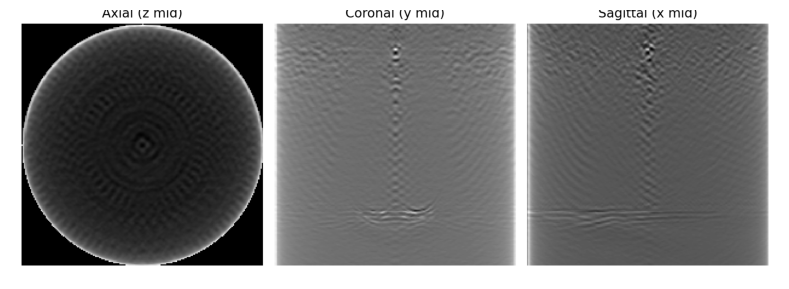

In [4]:
def main():
    images = list_pngs(IN_DIR)

    print("Files available in directory:")
    print(images)
    print()
    print(f"Input directory: {IN_DIR}")
    print(f"Output directory: {OUT_DIR}")

    if len(images) < 3:
        raise ValueError("Need at least 3 projection images to reconstruct anything meaningful.")

    proj = load_projections_from_files(IN_DIR, images)
    nang, h, w = proj.shape
    print(f"\nLoaded {nang} projections with size HxW = {h}x{w}")

    crop_size = min(h, w) 
    proj = center_crop_to_square(proj, crop_size)
    nang, h, w = proj.shape
    print(f"After crop: HxW = {h}x{w}")

    angle_start = 0.0
    angle_end = 180.0
    theta = np.linspace(angle_start, angle_end, nang, endpoint=False).astype(np.float32)
    print(f"Using angles from {angle_start}° to {angle_end}° (endpoint excluded), count={len(theta)}")

    volume = reconstruct_volume_slice_by_slice(
        proj=proj,
        theta_deg=theta,
        filter_name="hann",
        circle=True,
    )
    print(f"Reconstructed volume shape: {volume.shape}")

    out_npy = os.path.join(OUT_DIR, "recon_volume.npy")
    np.save(out_npy, volume)
    print(f"Saved volume: {out_npy}")

    preview_path = os.path.join(OUT_DIR, "preview.png")
    save_preview_png(volume, preview_path)
    print(f"Saved preview: {preview_path}")

    if display_picture.lower() == "y":
        img = iio.imread(preview_path)
        plt.figure(figsize=(10, 3.5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


if __name__ == "__main__":
    main()

File size: 30.52 MB
Volume shape: (200, 200, 200)


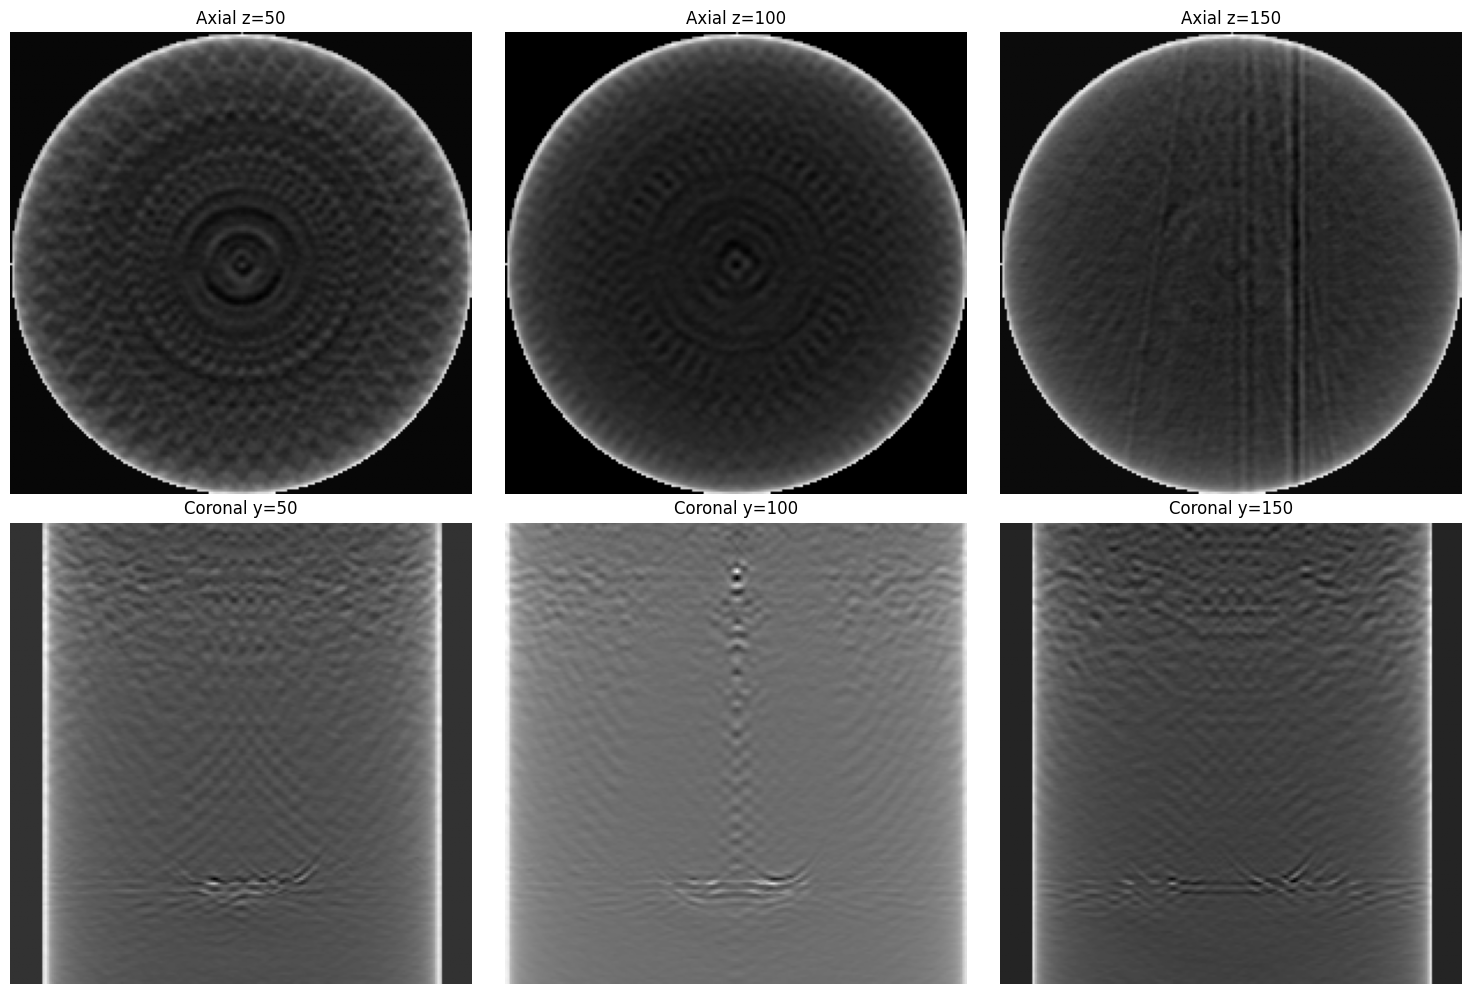

In [5]:
# Load the saved volume
file_path = os.path.join(OUT_DIR, "recon_volume.npy")
volume = np.load(file_path)
size_mb = os.path.getsize(file_path) / (1024**2)
print(f"File size: {size_mb:.2f} MB")
print(f"Volume shape: {volume.shape}")

# Quick static view - runs instantly
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Axial slices
for i, fraction in enumerate([0.25, 0.5, 0.75]):
    idx = int(volume.shape[0] * fraction)
    axes[0, i].imshow(volume[idx, :, :], cmap='gray')
    axes[0, i].set_title(f'Axial z={idx}')
    axes[0, i].axis('off')

# Coronal slices
for i, fraction in enumerate([0.25, 0.5, 0.75]):
    idx = int(volume.shape[1] * fraction)
    axes[1, i].imshow(volume[:, idx, :], cmap='gray')
    axes[1, i].set_title(f'Coronal y={idx}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Volume max: 1.0000e+00
Threshold at -7dB: 4.4668e-01
Generated 525880 vertices and 1040466 faces


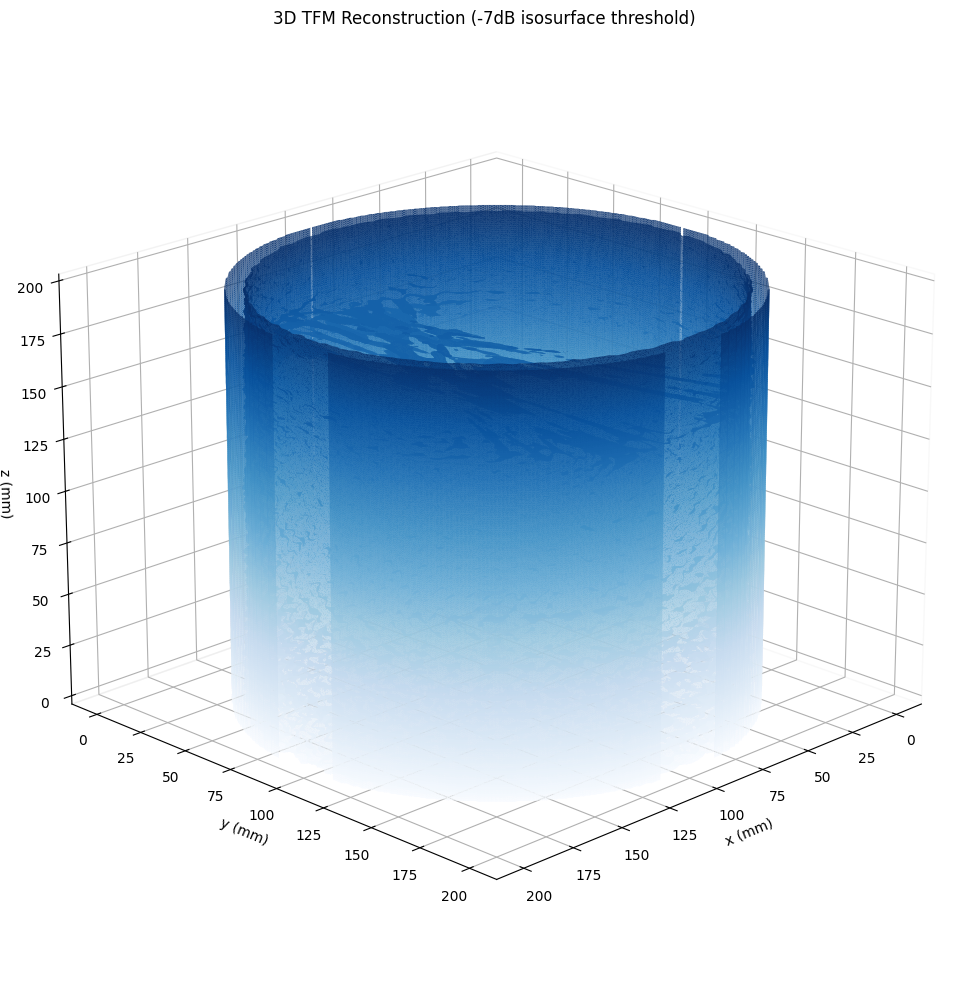

In [6]:
# 3D Isosurface Visualization with adjustable threshold
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure

# Normalize volume
volume_normalized = np.abs(volume)
volume_max = volume_normalized.max()
volume_db = 20 * np.log10(volume_normalized / volume_max + 1e-10)

# Try a higher threshold to see the hole clearly (adjust this value)
threshold_db = -7  # Changed from -6 to -3 to see interior features
threshold_linear = volume_max * 10**(threshold_db / 20)

print(f"Volume max: {volume_max:.4e}")
print(f"Threshold at {threshold_db}dB: {threshold_linear:.4e}")

# Create marching cubes isosurface
try:
    verts, faces, normals, values = measure.marching_cubes(volume_normalized, level=threshold_linear)
    print(f"Generated {len(verts)} vertices and {len(faces)} faces")
except:
    print("No surface found at this threshold. Try lowering threshold_db value.")
    raise

# Create figure with 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the isosurface
ax.plot_trisurf(verts[:, 2], verts[:, 1], faces, verts[:, 0],
                cmap='Blues', alpha=0.9, linewidth=0, shade=True,
                edgecolor='none', antialiased=True)

# Set labels and appearance
ax.set_xlabel('x (mm)', fontsize=10)
ax.set_ylabel('y (mm)', fontsize=10)
ax.set_zlabel('z (mm)', fontsize=10)
ax.set_title(f'3D TFM Reconstruction ({threshold_db}dB isosurface threshold)', fontsize=12)

# Set viewing angle
ax.view_init(elev=20, azim=45)

# Grid styling
ax.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.show()

Using threshold: -2dB = 79.4% of max
Number of voxels above threshold: 17447
Rendering 8724 points (subsampled from 17447)


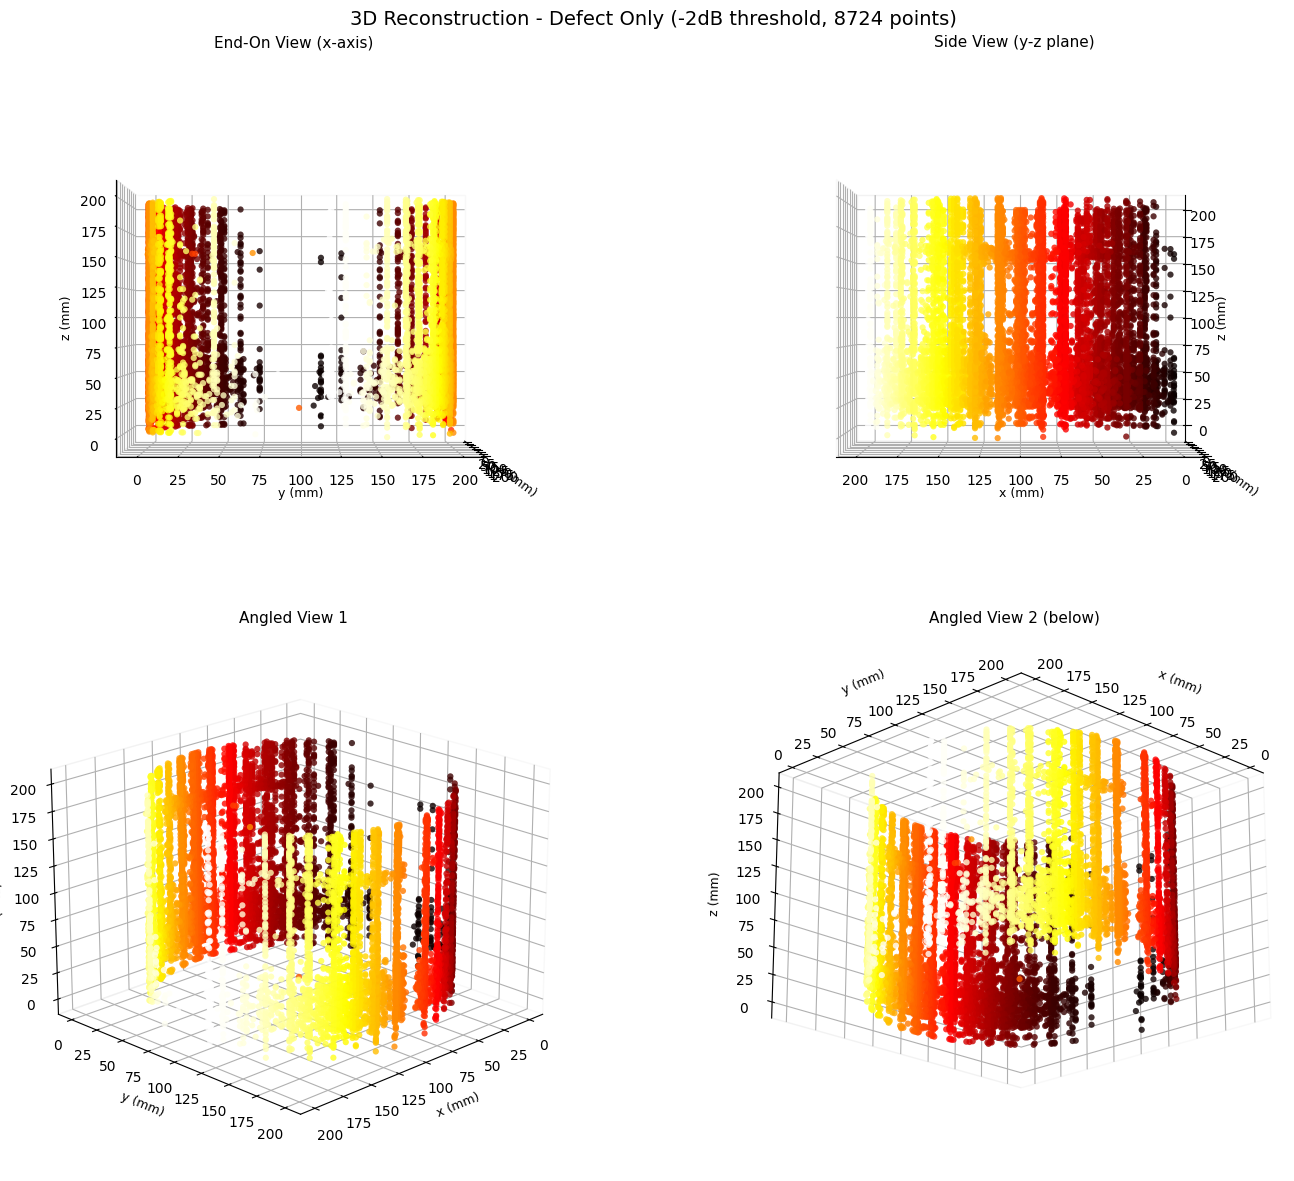

In [10]:
# Show ONLY the defect signals - much higher threshold
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Use MUCH HIGHER threshold to isolate only the bright defect signals
threshold_db = -2  # Very selective - only the brightest signals (the defect)
volume_normalized = np.abs(volume)
volume_max = volume_normalized.max()
threshold_linear = volume_max * 10**(threshold_db / 20)

print(f"Using threshold: {threshold_db}dB = {(threshold_linear/volume_max)*100:.1f}% of max")

# Create binary mask of voxels above threshold
mask = volume_normalized > threshold_linear
print(f"Number of voxels above threshold: {mask.sum()}")

if mask.sum() == 0:
    print("No voxels above threshold! Try lowering threshold_db (e.g., -1, -1.5, -2)")
else:
    # Get coordinates of voxels above threshold
    z_coords, y_coords, x_coords = np.where(mask)
    
    # Subsample if needed
    subsample = 2  # Lower subsample for more detail on sparse data
    z_sub = z_coords[::subsample]
    y_sub = y_coords[::subsample]
    x_sub = x_coords[::subsample]
    
    print(f"Rendering {len(z_sub)} points (subsampled from {len(z_coords)})")
    
    # Create 4 different viewing angles optimized for horizontal defect
    fig = plt.figure(figsize=(16, 12))
    
    viewing_angles = [
        (0, 0, 'End-On View (x-axis)'),      # Look straight through the hole
        (0, 90, 'Side View (y-z plane)'),    # Side view perpendicular to hole
        (20, 45, 'Angled View 1'),
        (-20, 45, 'Angled View 2 (below)')
    ]
    
    for idx, (elev, azim, title) in enumerate(viewing_angles, 1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        
        # Scatter plot colored by x-position
        scatter = ax.scatter(x_sub, y_sub, z_sub, 
                             c=x_sub, cmap='hot', 
                             s=20, alpha=0.8, 
                             marker='o', edgecolors='none')
        
        ax.set_xlabel('x (mm)', fontsize=9)
        ax.set_ylabel('y (mm)', fontsize=9)
        ax.set_zlabel('z (mm)', fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.view_init(elev=elev, azim=azim)
        
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
    
    plt.suptitle(f'3D Reconstruction - Defect Only ({threshold_db}dB threshold, {len(z_sub)} points)', 
                 fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

Volume shape: (200, 200, 200)
Volume min: 0.0000, max: 1.0000
Volume mean: 0.3690, std: 0.0876


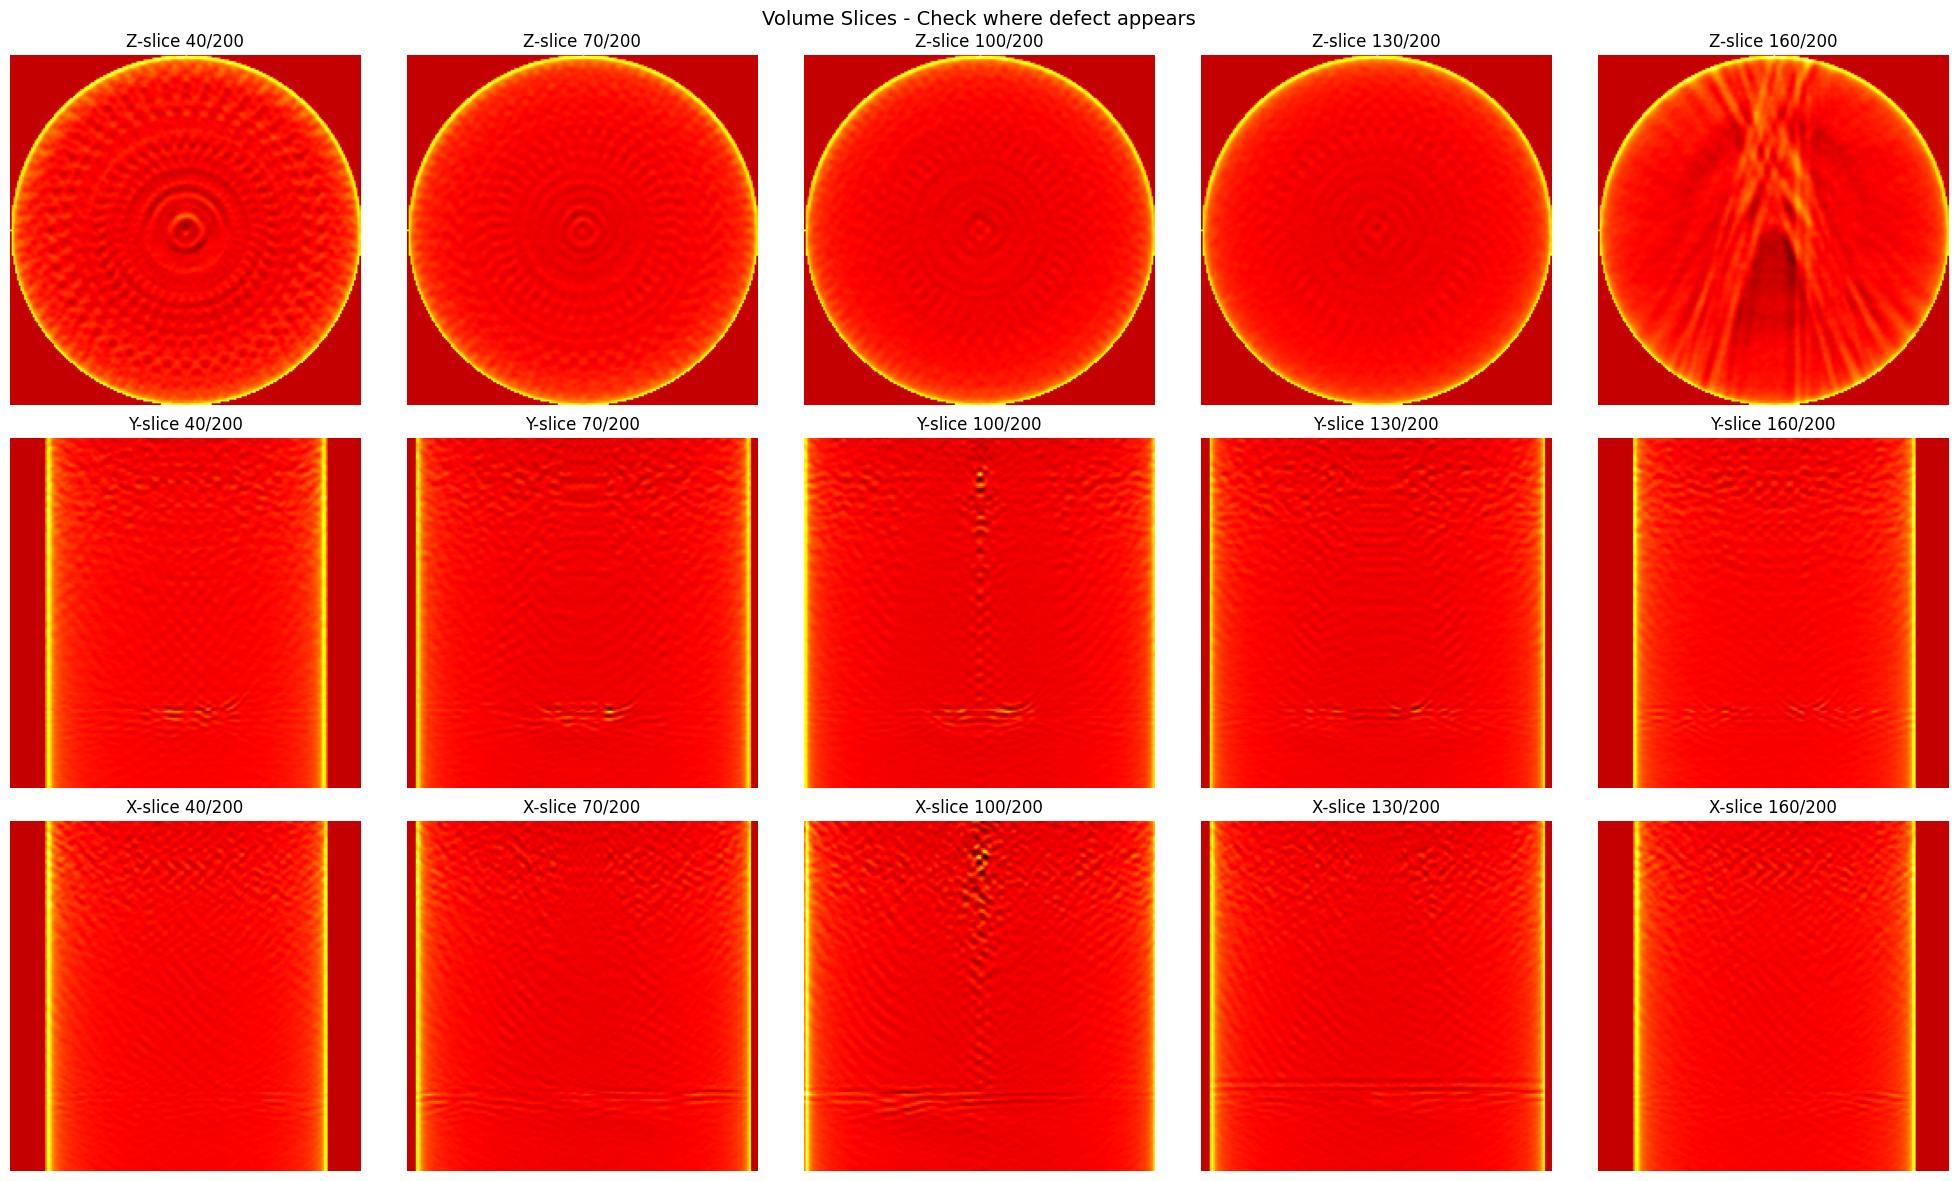


Look for the horizontal line pattern (the defect) in the slices above.
The defect should appear as a bright horizontal feature.


In [11]:
# Debug: Check what the volume actually looks like in different slices
import matplotlib.pyplot as plt

# Load volume
file_path = os.path.join(OUT_DIR, "recon_volume.npy")
volume = np.load(file_path)

print(f"Volume shape: {volume.shape}")
print(f"Volume min: {volume.min():.4f}, max: {volume.max():.4f}")
print(f"Volume mean: {volume.mean():.4f}, std: {volume.std():.4f}")

# Show slices through all three axes to understand orientation
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Z-axis slices (axial)
for i, fraction in enumerate([0.2, 0.35, 0.5, 0.65, 0.8]):
    idx = int(volume.shape[0] * fraction)
    im = axes[0, i].imshow(volume[idx, :, :], cmap='hot', vmin=0, vmax=volume.max())
    axes[0, i].set_title(f'Z-slice {idx}/{volume.shape[0]}')
    axes[0, i].axis('off')

# Y-axis slices (coronal)
for i, fraction in enumerate([0.2, 0.35, 0.5, 0.65, 0.8]):
    idx = int(volume.shape[1] * fraction)
    im = axes[1, i].imshow(volume[:, idx, :], cmap='hot', vmin=0, vmax=volume.max())
    axes[1, i].set_title(f'Y-slice {idx}/{volume.shape[1]}')
    axes[1, i].axis('off')

# X-axis slices (sagittal)
for i, fraction in enumerate([0.2, 0.35, 0.5, 0.65, 0.8]):
    idx = int(volume.shape[2] * fraction)
    im = axes[2, i].imshow(volume[:, :, idx], cmap='hot', vmin=0, vmax=volume.max())
    axes[2, i].set_title(f'X-slice {idx}/{volume.shape[2]}')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Z-axis (depth)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Y-axis', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('X-axis', fontsize=12, fontweight='bold')

plt.suptitle('Volume Slices - Check where defect appears', fontsize=14)
plt.tight_layout()
plt.show()

# Show which axis has the defect clearly visible
print("\nLook for the horizontal line pattern (the defect) in the slices above.")
print("The defect should appear as a bright horizontal feature.")

Original volume range: 0.0000 to 1.0000
Interior volume range: 0.0000 to 0.8543
Using 95th percentile threshold: 0.4041
Number of voxels in defect: 196000
Rendering 196000 defect points


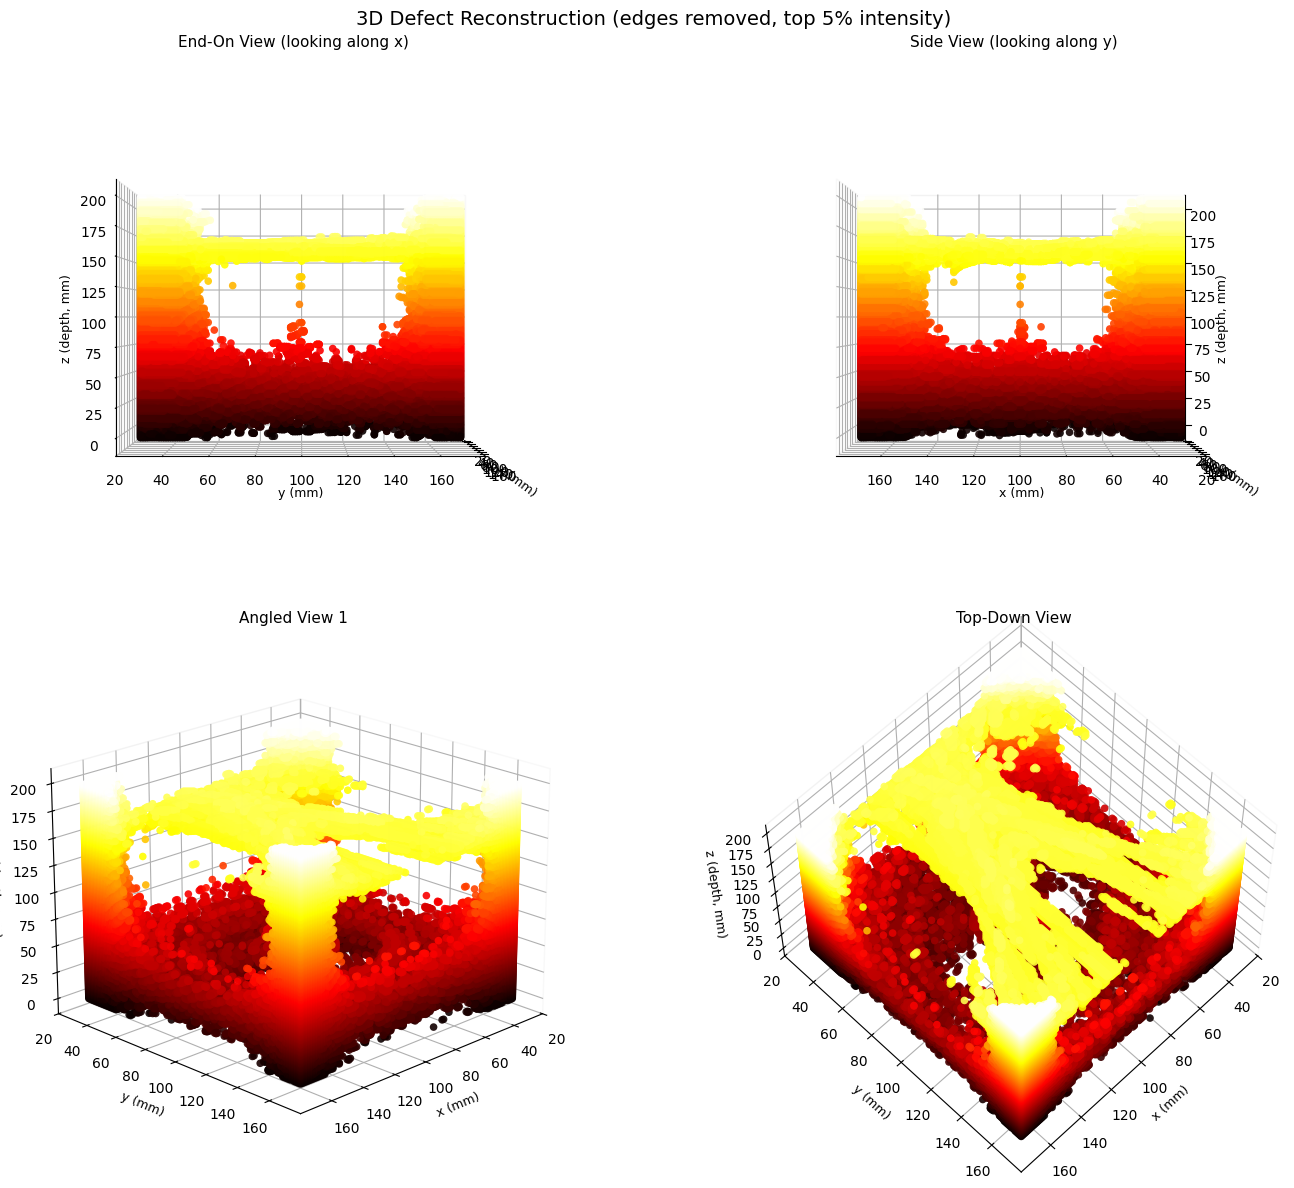

In [12]:
# Remove edge artifacts and visualize only the interior defect
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load volume
volume = np.load(os.path.join(OUT_DIR, "recon_volume.npy"))

# Create a mask to exclude edge artifacts (remove outer ~15% on each side)
z, y, x = volume.shape
margin = int(0.15 * min(y, x))  # 15% margin
mask_interior = np.zeros_like(volume, dtype=bool)
mask_interior[:, margin:-margin, margin:-margin] = True

# Apply mask to remove edges
volume_interior = volume.copy()
volume_interior[~mask_interior] = 0

print(f"Original volume range: {volume.min():.4f} to {volume.max():.4f}")
print(f"Interior volume range: {volume_interior.min():.4f} to {volume_interior.max():.4f}")

# Threshold to show only defect (adjust this value)
threshold_percentile = 95  # Show top 5% of intensity
threshold_value = np.percentile(volume_interior[volume_interior > 0], threshold_percentile)

print(f"Using {threshold_percentile}th percentile threshold: {threshold_value:.4f}")

# Create mask for defect
defect_mask = (volume_interior > threshold_value) & mask_interior
print(f"Number of voxels in defect: {defect_mask.sum()}")

if defect_mask.sum() > 0:
    # Get coordinates
    z_coords, y_coords, x_coords = np.where(defect_mask)
    
    # Subsample
    subsample = 1  # No subsampling for sparse defect data
    z_sub = z_coords[::subsample]
    y_sub = y_coords[::subsample]
    x_sub = x_coords[::subsample]
    
    print(f"Rendering {len(z_sub)} defect points")
    
    # Create 4 viewing angles
    fig = plt.figure(figsize=(16, 12))
    
    viewing_angles = [
        (0, 0, 'End-On View (looking along x)'),
        (0, 90, 'Side View (looking along y)'),
        (20, 45, 'Angled View 1'),
        (60, 45, 'Top-Down View')
    ]
    
    for idx, (elev, azim, title) in enumerate(viewing_angles, 1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        
        # Color by z-depth
        scatter = ax.scatter(x_sub, y_sub, z_sub, 
                             c=z_sub, cmap='hot', 
                             s=30, alpha=0.9, 
                             marker='o', edgecolors='none')
        
        ax.set_xlabel('x (mm)', fontsize=9)
        ax.set_ylabel('y (mm)', fontsize=9)
        ax.set_zlabel('z (depth, mm)', fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.view_init(elev=elev, azim=azim)
        
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
    
    plt.suptitle(f'3D Defect Reconstruction (edges removed, top {100-threshold_percentile}% intensity)', 
                 fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print(f"No defect found! Try lower percentile (e.g., 90, 85, 80)")